# Explore here

In [9]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv')
df



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [10]:
#toma el DataFrame df y lo guarda como un archivo CSV llamado raw_data.csv en la carpeta data/raw, que se encuentra un nivel por encima del directorio actual, y lo hace sin guardar el index del dataframe.
df.to_csv('../data/raw/raw_data.scv',index=False)

In [11]:
df=df.drop_duplicates()
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


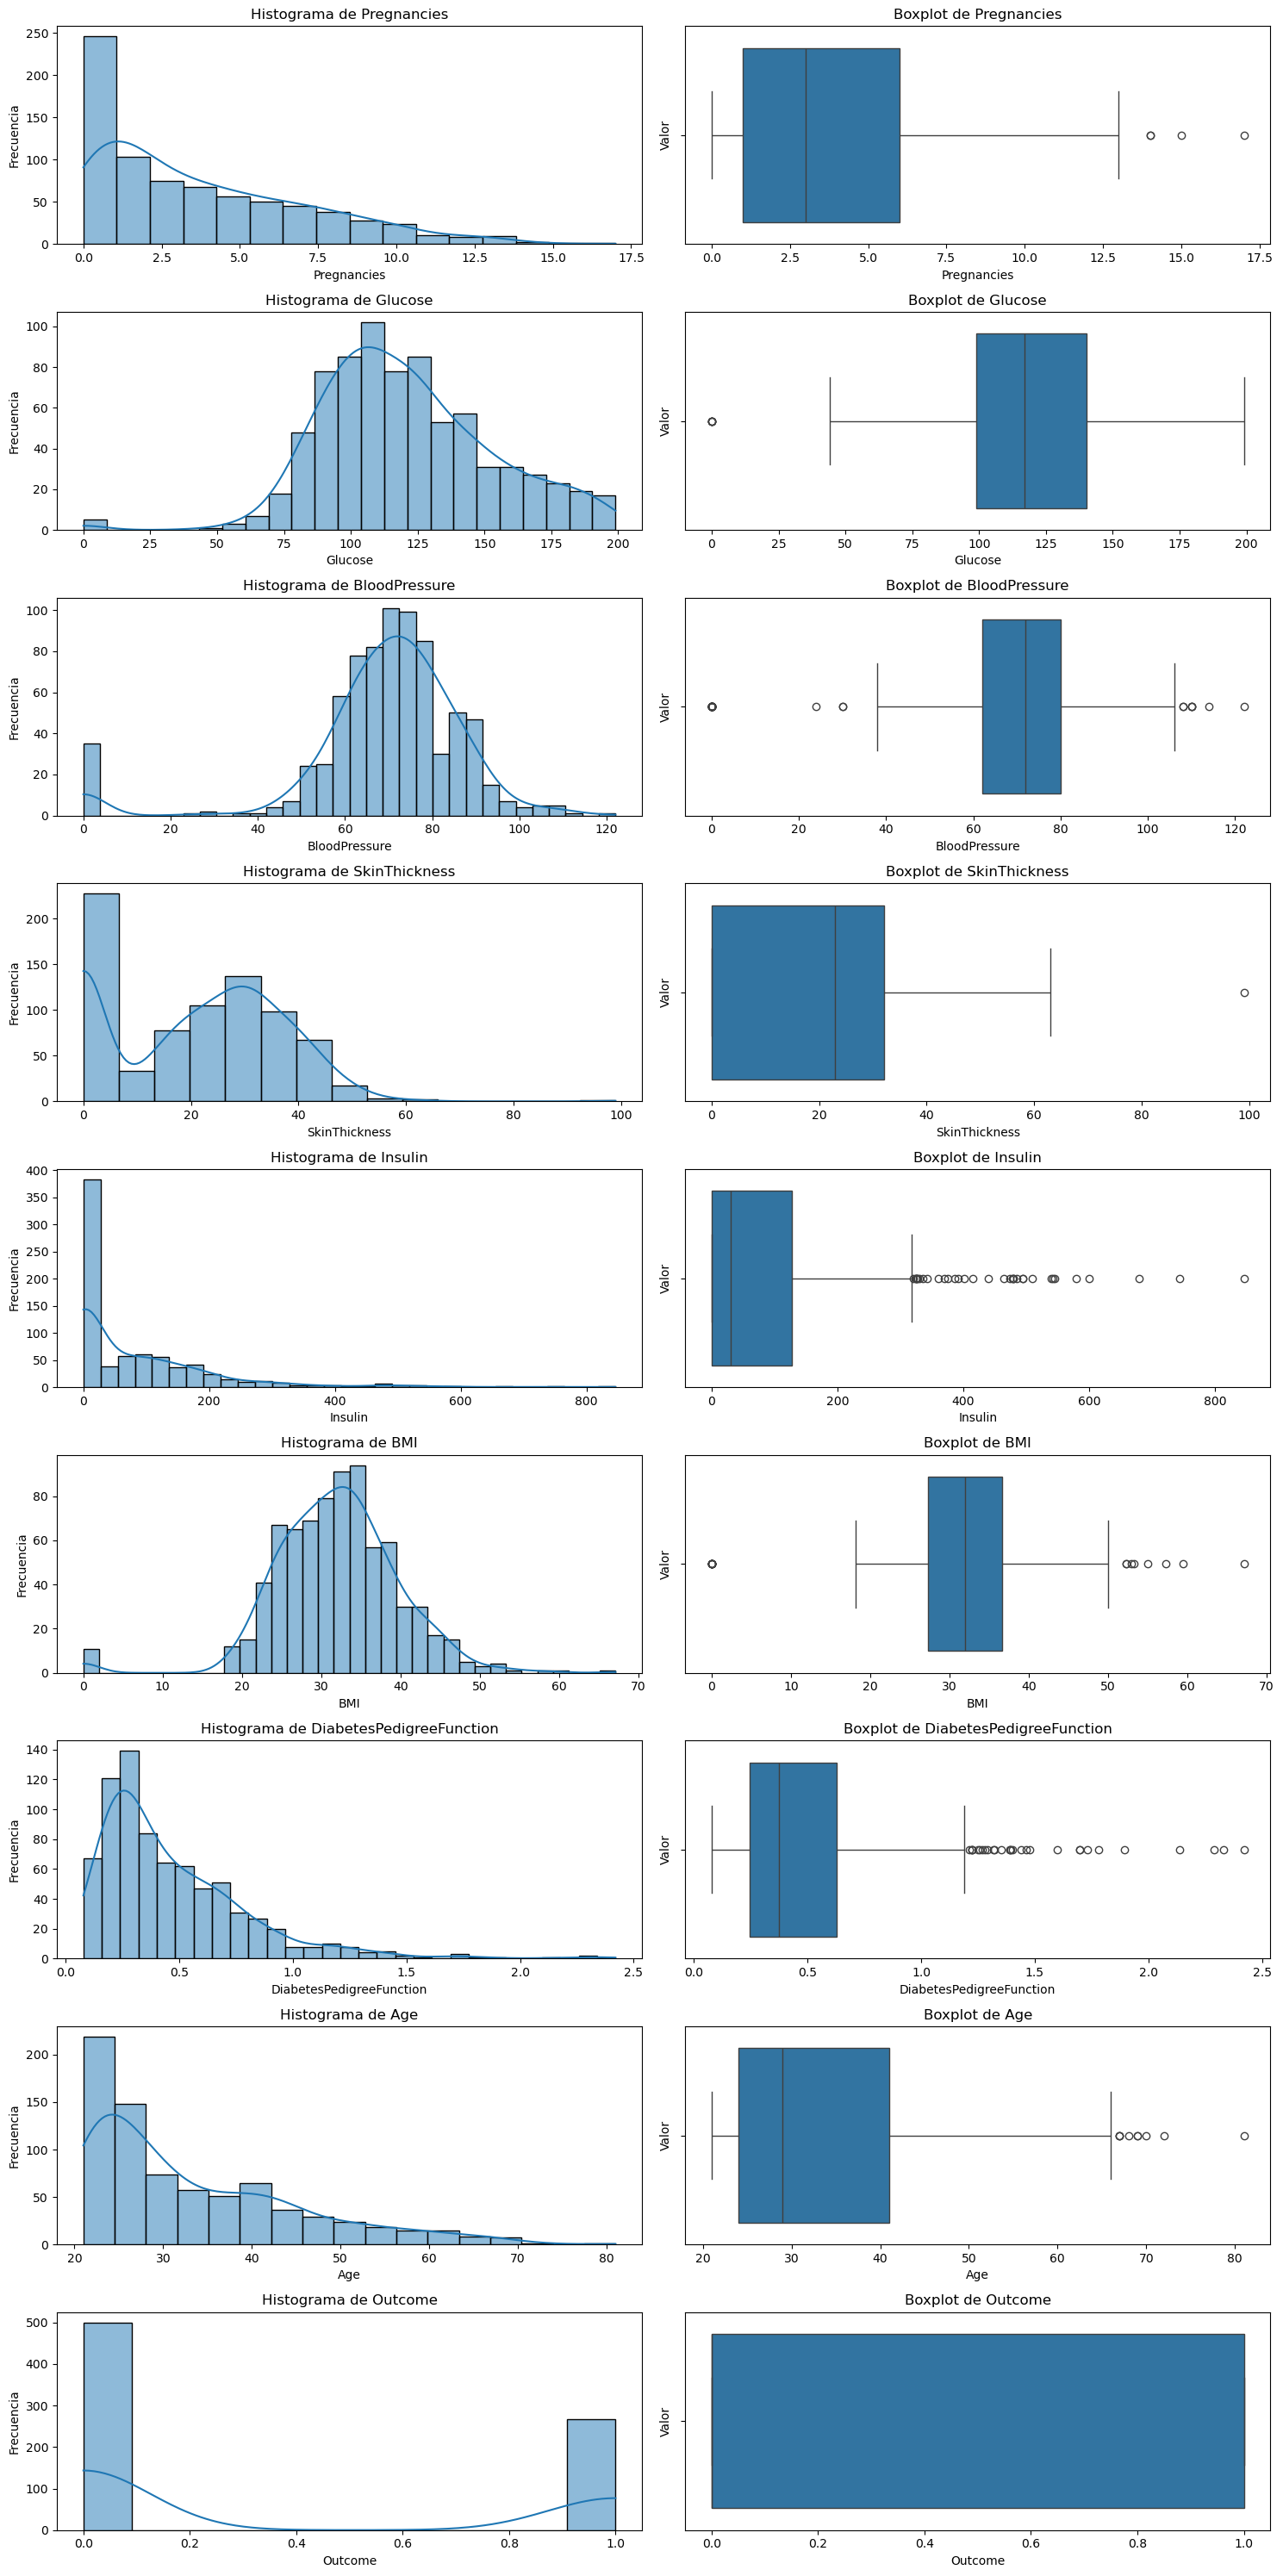

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(9, 2, figsize=(15, 30))

variables_numericas = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

for i, variable in enumerate(variables_numericas):
    # Histograma
    sns.histplot(ax=axes[i, 0], data=df, x=variable, kde=True)  # kde para suavizar la curva
    axes[i, 0].set_title(f"Histograma de {variable}")
    axes[i, 0].set_xlabel(variable)
    axes[i, 0].set_ylabel("Frecuencia")

    # Boxplot
    sns.boxplot(ax=axes[i, 1], data=df, x=variable)
    axes[i, 1].set_title(f"Boxplot de {variable}")
    axes[i, 1].set_xlabel(variable)
    axes[i, 1].set_ylabel("Valor")  # Ajusta la etiqueta del eje y

plt.tight_layout()
plt.show()


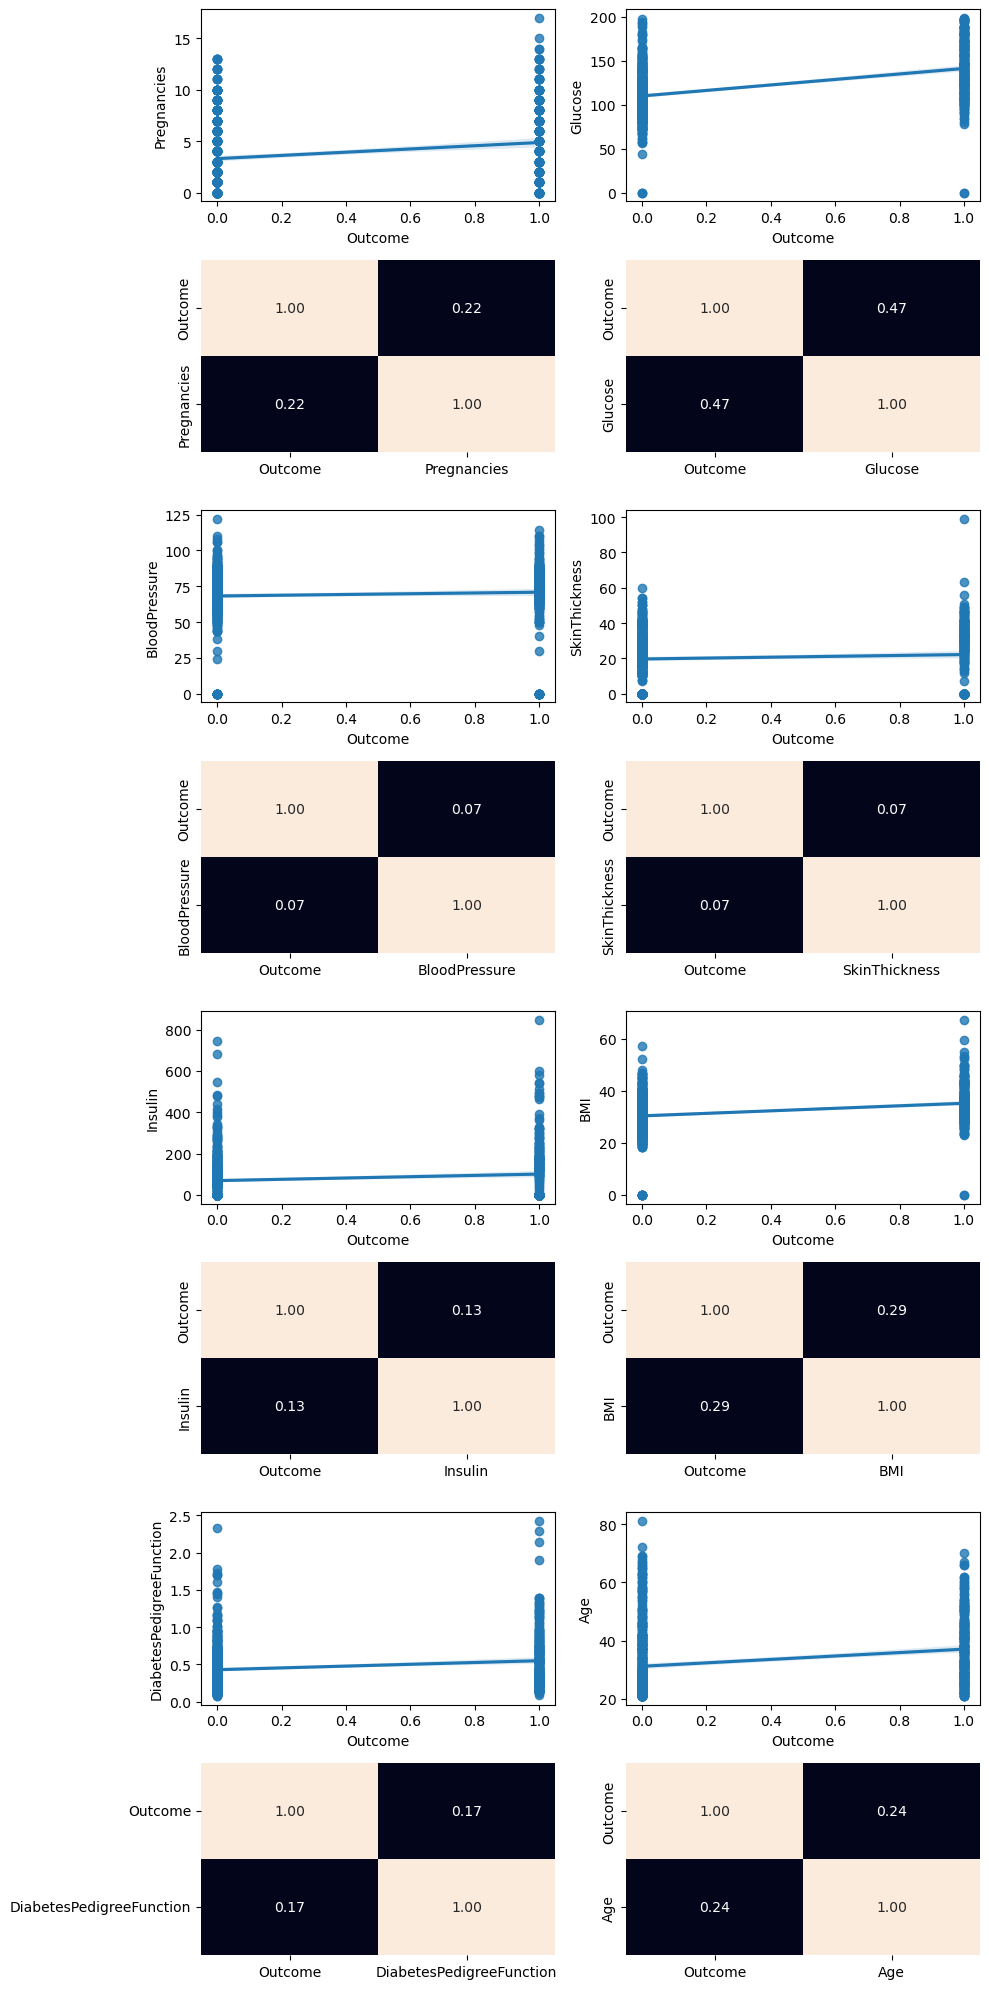

In [13]:
#analisis multivariante
#numerico-numerico
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(8, 2, figsize=(10, 20))

sns.regplot(ax=axes[0, 0], data=df, x="Outcome", y="Pregnancies")
sns.heatmap(df[["Outcome", "Pregnancies"]].corr(), annot=True, fmt=".2f", ax=axes[1, 0], cbar=False)

sns.regplot(ax=axes[0, 1], data=df, x="Outcome", y="Glucose")
sns.heatmap(df[["Outcome", "Glucose"]].corr(), annot=True, fmt=".2f", ax=axes[1, 1], cbar=False)

sns.regplot(ax=axes[2, 0], data=df, x="Outcome", y="BloodPressure") # Corregido
sns.heatmap(df[["Outcome", "BloodPressure"]].corr(), annot=True, fmt=".2f", ax=axes[3, 0], cbar=False)

sns.regplot(ax=axes[2, 1], data=df, x="Outcome", y="SkinThickness") # Corregido
sns.heatmap(df[["Outcome", "SkinThickness"]].corr(), annot=True, fmt=".2f", ax=axes[3, 1], cbar=False)

sns.regplot(ax=axes[4, 0], data=df, x="Outcome", y="Insulin") # Corregido
sns.heatmap(df[["Outcome", "Insulin"]].corr(), annot=True, fmt=".2f", ax=axes[5, 0], cbar=False)

sns.regplot(ax=axes[4, 1], data=df, x="Outcome", y="BMI") # Corregido
sns.heatmap(df[["Outcome", "BMI"]].corr(), annot=True, fmt=".2f", ax=axes[5, 1], cbar=False)

sns.regplot(ax=axes[6, 0], data=df, x="Outcome", y="DiabetesPedigreeFunction") # Corregido
sns.heatmap(df[["Outcome", "DiabetesPedigreeFunction"]].corr(), annot=True, fmt=".2f", ax=axes[7, 0], cbar=False)

sns.regplot(ax=axes[6, 1], data=df, x="Outcome", y="Age") # Corregido
sns.heatmap(df[["Outcome", "Age"]].corr(), annot=True, fmt=".2f", ax=axes[7, 1], cbar=False)

plt.tight_layout() 
plt.show()

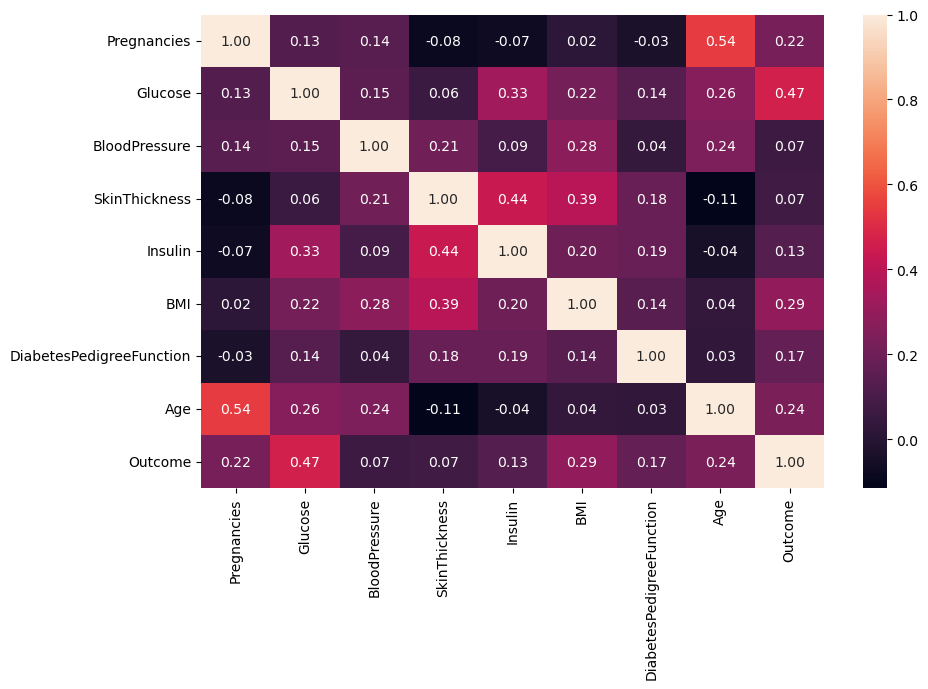

In [14]:
fit, axis=plt.subplots(figsize=(10,7))

sns.heatmap(df._get_numeric_data().corr(), annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

In [16]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [18]:
df.groupby('Outcome')['Glucose'].mean()

Outcome
0    109.980000
1    141.257463
Name: Glucose, dtype: float64

In [19]:
df.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [ ]:
#vamos a mejorar la precision del modelo. para eso buscaremos los outliers y ver su percentil

df.describe()

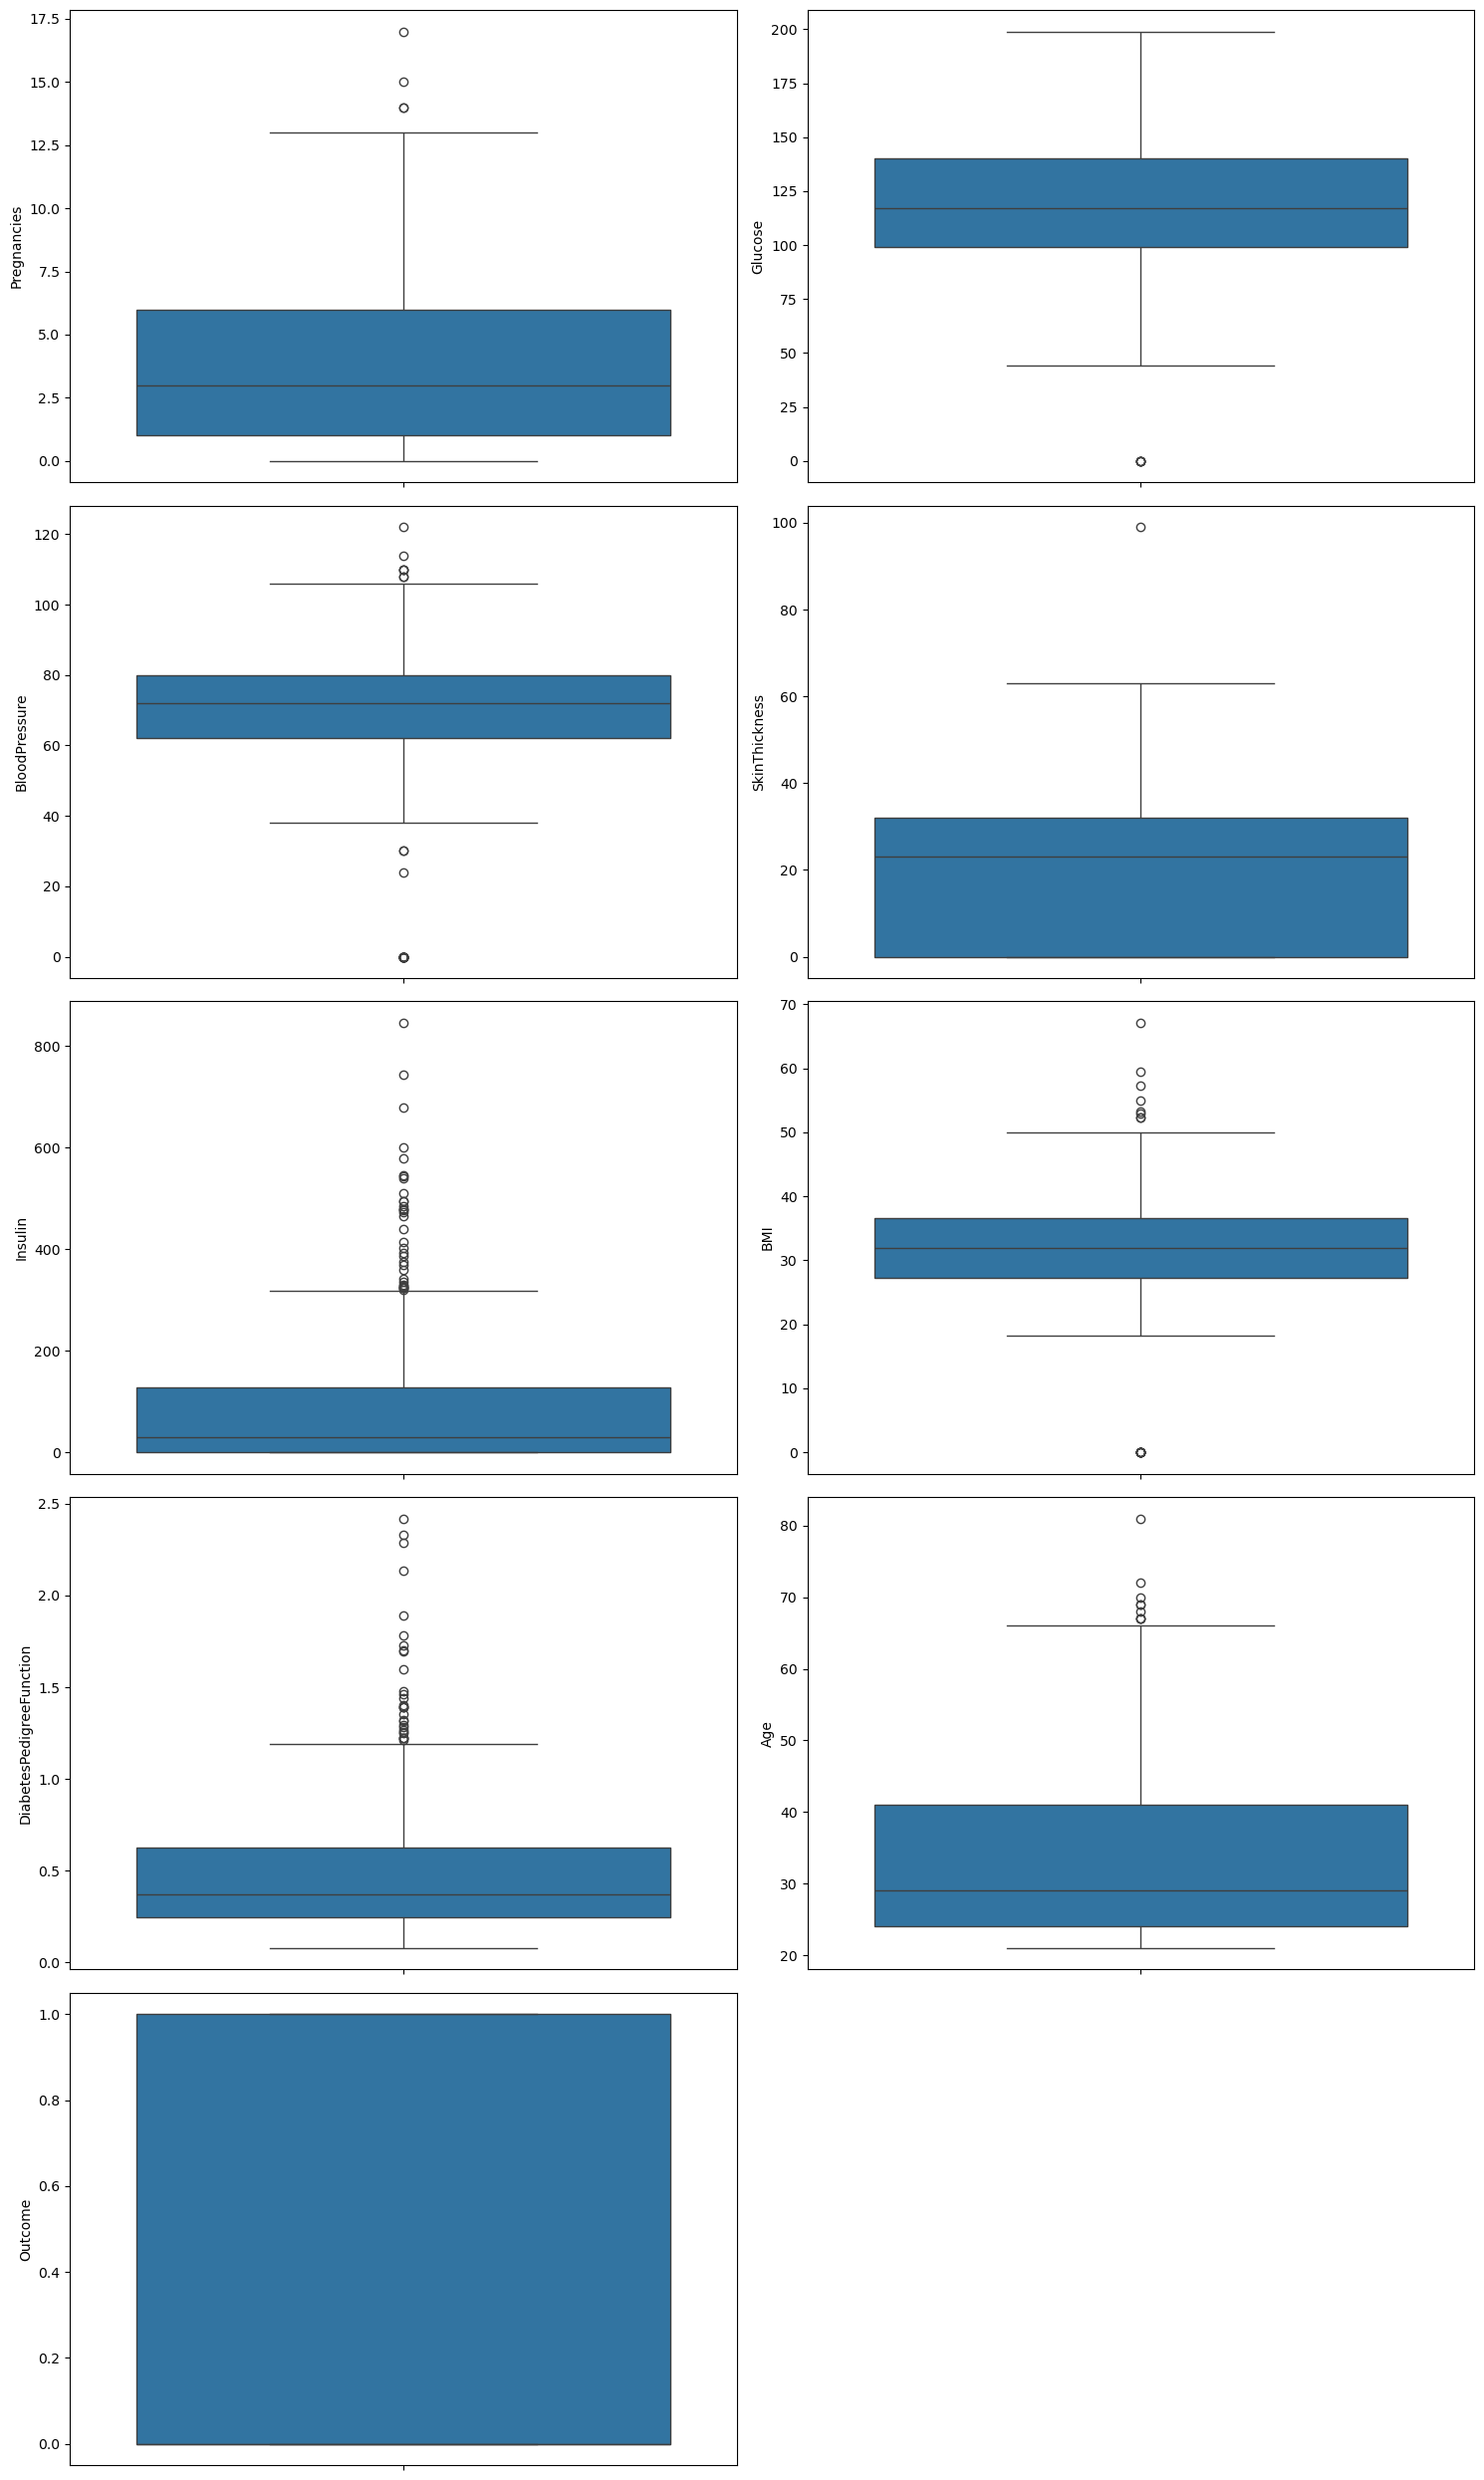

In [20]:
#Dibujar los diagramas de cajas de las variables también nos da una información muy poderosa sobre los valores atípicos
import numpy as np


nuevas_variables = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

num_variables = len(nuevas_variables)
num_rows = (num_variables + 1) // 2 

fig, axes = plt.subplots(num_rows, 2, figsize=(15, num_rows * 5)) 

for i, col in enumerate(nuevas_variables):
    row = i // 2  
    col_index = i % 2  
    sns.boxplot(ax=axes[row, col_index], data=df, y=col)

if num_variables % 2 != 0:
    axes[-1, 1].set_visible(False)

plt.tight_layout()
plt.show()

In [23]:
#basandome y analizando el boxplot de las variables numericas y el boxplot de las nuevas variables, solo pondermos edad no mayor a 70 años y poutcome que fue exitoso

preg_stats = df["Pregnancies"].describe()
preg_stats

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

In [24]:
preg_iqr = preg_stats["75%"] - preg_stats["25%"]
upper_limit = preg_stats["75%"] + 1.5 * preg_iqr
lower_limit = preg_stats["25%"] - 1.5 * preg_iqr

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(preg_iqr, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 13.5 y -6.5, con un rango intercuartílico de 5.0


In [33]:
df.isnull().sum().sort_values(ascending=False) / len(df)

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

In [34]:
from sklearn.model_selection import train_test_split

num_variables = ['Glucose']

# Dividimos el conjunto de datos en muestras de train y test
X = df.drop("Outcome", axis = 1)[num_variables]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.head()

#separo el conjunto de datos para entrenar

,Glucose
60,84
618,112
346,139
294,161
231,134


In [35]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

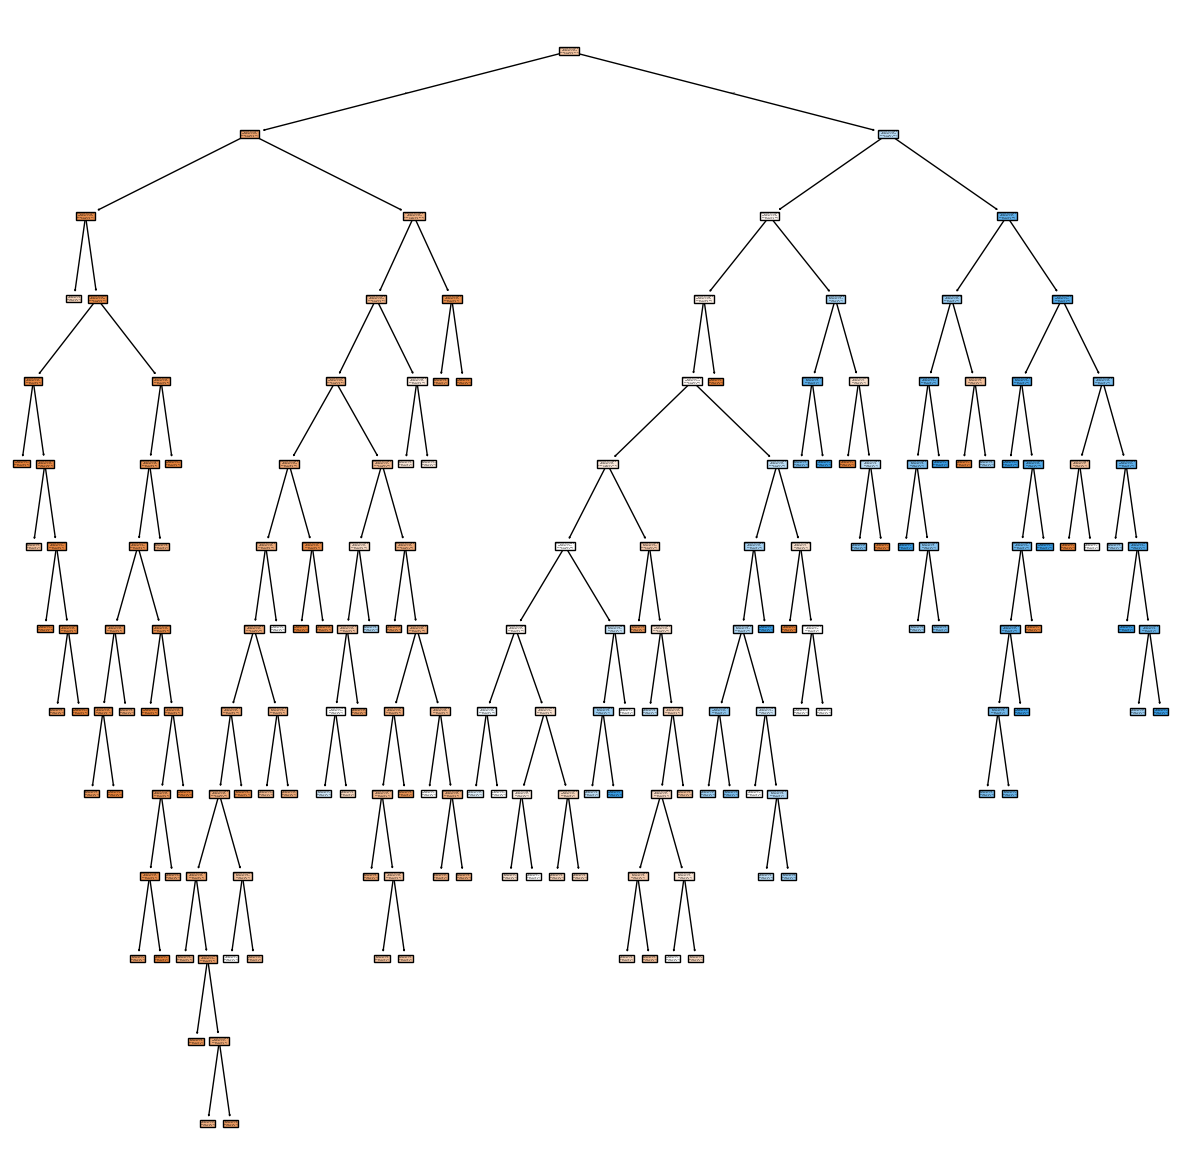

In [36]:
import matplotlib.pyplot as plt
from sklearn import tree

fig = plt.figure(figsize=(15,15))

tree.plot_tree(model, feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)

plt.show()

In [37]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
      dtype=int64)

In [38]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.6688311688311688